# Hard coal NPV simulation

Run the hard coal electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_npv_monte_carlo import simulate_hard_coal_npv


In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_hard_coal_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2185.231693,40.617384,4.398327,2.511004,...,94070000.0,9.906679e+06,4.398327e+06,4.540897e+07,7.150849e+07,-3.715247e+07,-9.295776e+08,25000000.0,-37.183104,-0.000037
1,1,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2269.330315,46.274748,4.681683,2.449029,...,94070000.0,1.128652e+07,4.681683e+06,2.327882e+07,7.009796e+07,-1.527498e+07,-7.165522e+08,25000000.0,-28.662089,-0.000029
2,2,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2210.135059,41.492511,4.937959,2.541465,...,94070000.0,1.012012e+07,4.937959e+06,2.547888e+07,6.893471e+07,-1.540168e+07,-7.034668e+08,25000000.0,-28.138672,-0.000028
3,3,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2022.208433,36.831610,5.534140,2.559486,...,94070000.0,8.983320e+06,5.534140e+06,2.540043e+07,7.309793e+07,-1.894582e+07,-6.954640e+08,25000000.0,-27.818560,-0.000028
4,4,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2056.927322,39.354807,6.269583,2.571081,...,94070000.0,9.598733e+06,6.269583e+06,3.469520e+07,7.212560e+07,-2.861912e+07,-8.071923e+08,25000000.0,-32.287690,-0.000032


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-715.960613,-28.638425,-0.000029
std,78.593026,3.143721,0.000003
min,-1124.716875,-44.988675,-0.000045
5%,-854.746573,-34.189863,-0.000034
50%,-710.732148,-28.429286,-0.000028
95%,-595.577377,-23.823095,-0.000024
max,-490.161124,-19.606445,-0.000020


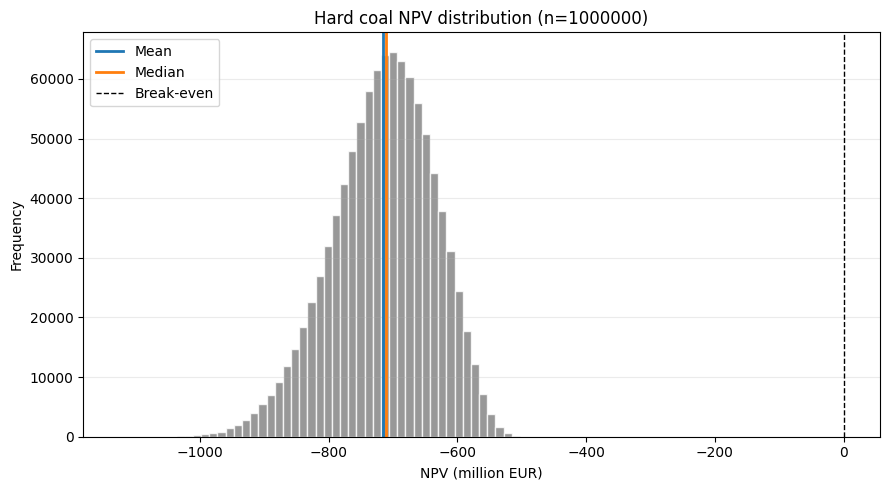

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

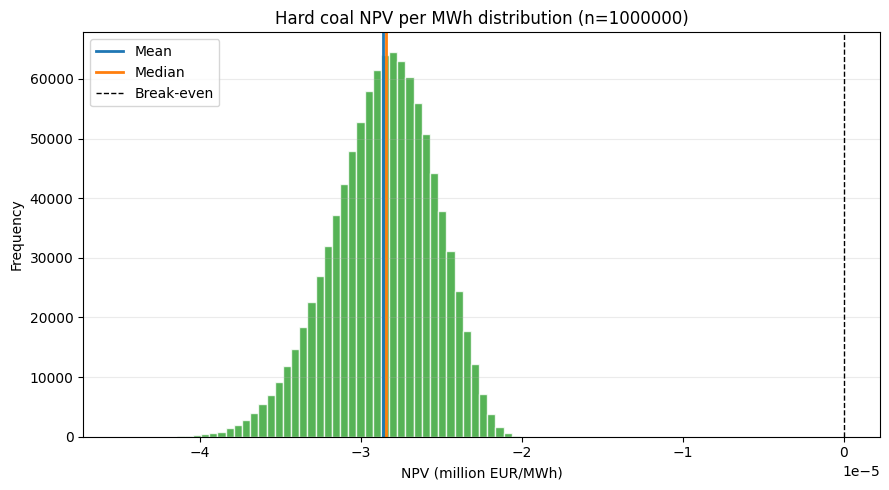

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.326757
annual_variable_opex_eur      5.166740
annual_fuel_cost_eur         31.076643
annual_emissions_cost_eur    69.866033
annual_net_cash_flow_eur    -21.366173
Name: Mean annual value, million EUR, dtype: float64